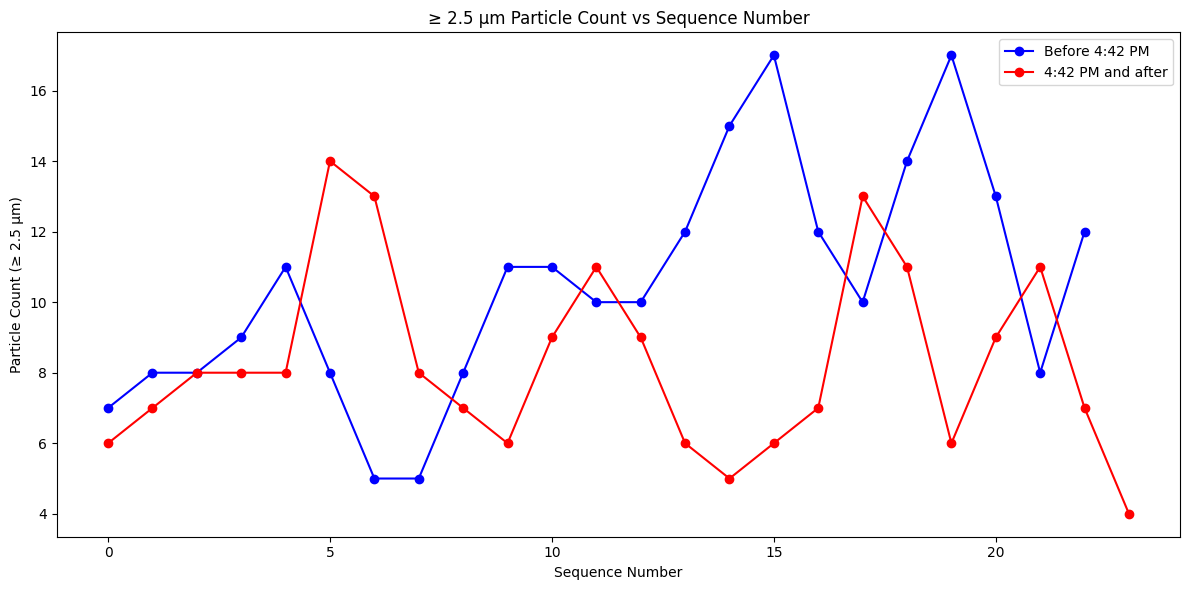

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to your CSV file
file_path = "/Users/vivianzhang/opencs/student/_data/csv-temp (2).csv"

# Column names (ignore the extra time column at the end)
columns = [
    "time",
    "longitude",
    "latitude",
    ">= 0.3µm",
    ">= 0.5µm",
    ">= 1.0µm",
    ">= 2.5µm",
    ">= 5.0µm",
    ">= 10.0µm"
]

# Read CSV and handle "null" as NaN
df = pd.read_csv(file_path, usecols=range(len(columns)), names=columns, header=0, na_values="null")

# Convert 'time' to datetime (today's date + time)
df["time"] = pd.to_datetime(df["time"], format="%I:%M:%S %p", errors="coerce")

# Drop rows with invalid times
df = df.dropna(subset=["time"])

# Convert particle counts to numeric
particle_columns = [">= 0.3µm", ">= 0.5µm", ">= 1.0µm", ">= 2.5µm", ">= 5.0µm", ">= 10.0µm"]
for col in particle_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Sort by time
df = df.sort_values("time").reset_index(drop=True)  # reset index for sequence number

# Split the data into two parts
split_time = pd.to_datetime("4:42:00 PM", format="%I:%M:%S %p")
before_split = df[df["time"] < split_time].reset_index(drop=True)
after_split = df[df["time"] >= split_time].reset_index(drop=True)

# Plotting against sequence number
plt.figure(figsize=(12, 6))
plt.plot(before_split.index, before_split[">= 2.5µm"], color="blue", label="Before 4:42 PM", marker="o")
plt.plot(after_split.index, after_split[">= 2.5µm"], color="red", label="4:42 PM and after", marker="o")

plt.xlabel("Sequence Number")
plt.ylabel("Particle Count (≥ 2.5 µm)")
plt.title("≥ 2.5 µm Particle Count vs Sequence Number")
plt.legend()
plt.tight_layout()
plt.show()


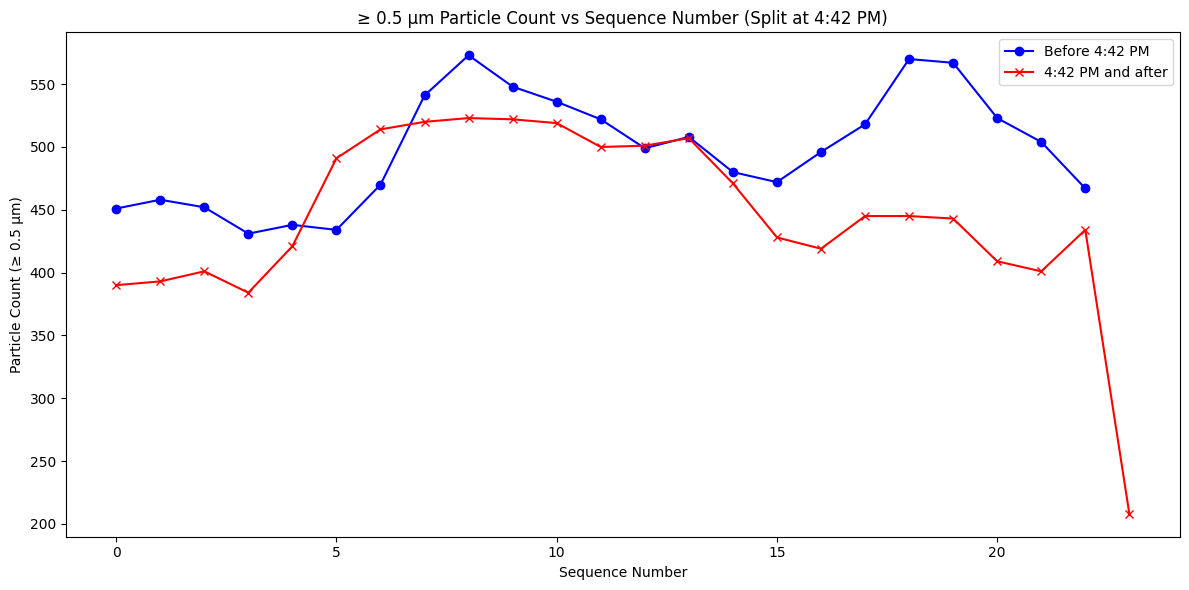

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to your CSV file
file_path = "/Users/vivianzhang/opencs/student/_data/csv-temp (2).csv"

# Column names (ignore the extra time column at the end)
columns = [
    "time",
    "longitude",
    "latitude",
    ">= 0.3µm",
    ">= 0.5µm",
    ">= 1.0µm",
    ">= 2.5µm",
    ">= 5.0µm",
    ">= 10.0µm"
]

# Read CSV and handle "null" as NaN
df = pd.read_csv(file_path, usecols=range(len(columns)), names=columns, header=0, na_values="null")

# Convert 'time' to datetime (today's date + time)
df["time"] = pd.to_datetime(df["time"], format="%I:%M:%S %p", errors="coerce")

# Drop rows with invalid times
df = df.dropna(subset=["time"])

# Convert '>= 0.5µm' column to numeric
df[">= 0.5µm"] = pd.to_numeric(df[">= 0.5µm"], errors="coerce")

# Sort by time and reset index for sequence number
df = df.sort_values("time").reset_index(drop=True)

# Split the data at 4:42 PM
split_time = pd.to_datetime("4:42:00 PM", format="%I:%M:%S %p")
before_split = df[df["time"] < split_time].reset_index(drop=True)
after_split = df[df["time"] >= split_time].reset_index(drop=True)

# Plotting ≥ 0.5 µm particle count
plt.figure(figsize=(12, 6))
plt.plot(before_split.index, before_split[">= 0.5µm"], color="blue", marker="o", linestyle="-", label="Before 4:42 PM")
plt.plot(after_split.index, after_split[">= 0.5µm"], color="red", marker="x", linestyle="-", label="4:42 PM and after")

plt.xlabel("Sequence Number")
plt.ylabel("Particle Count (≥ 0.5 µm)")
plt.title("≥ 0.5 µm Particle Count vs Sequence Number (Split at 4:42 PM)")
plt.legend()
plt.tight_layout()
plt.show()


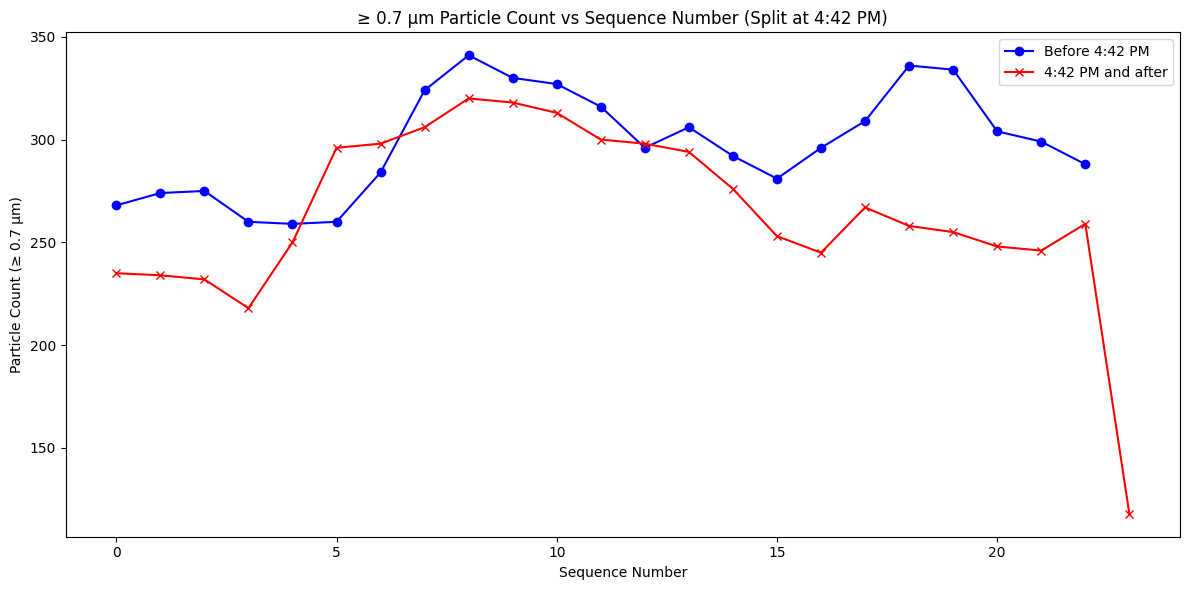

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to your CSV file
file_path = "/Users/vivianzhang/opencs/student/_data/csv-temp (2).csv"

# Column names (ignore the extra time column at the end)
columns = [
    "time",
    "longitude",
    "latitude",
    ">= 0.3µm",
    ">= 0.5µm",
    ">= 1.0µm",
    ">= 2.5µm",
    ">= 5.0µm",
    ">= 10.0µm"
]

# Read CSV and handle "null" as NaN
df = pd.read_csv(file_path, usecols=range(len(columns)), names=columns, header=0, na_values="null")

# Convert 'time' to datetime (today's date + time)
df["time"] = pd.to_datetime(df["time"], format="%I:%M:%S %p", errors="coerce")

# Drop rows with invalid times
df = df.dropna(subset=["time"])

# Since your dataset does not have a 0.7 µm column, let's interpolate it:
# We'll estimate it as the average of >=0.5µm and >=1.0µm counts
df[">= 0.7µm"] = ((df[">= 0.5µm"] + df[">= 1.0µm"]) / 2).round().astype(int)

# Sort by time and reset index for sequence number
df = df.sort_values("time").reset_index(drop=True)

# Split the data at 4:42 PM
split_time = pd.to_datetime("4:42:00 PM", format="%I:%M:%S %p")
before_split = df[df["time"] < split_time].reset_index(drop=True)
after_split = df[df["time"] >= split_time].reset_index(drop=True)

# Plotting ≥ 0.7 µm particle count
plt.figure(figsize=(12, 6))
plt.plot(before_split.index, before_split[">= 0.7µm"], color="blue", marker="o", linestyle="-", label="Before 4:42 PM")
plt.plot(after_split.index, after_split[">= 0.7µm"], color="red", marker="x", linestyle="-", label="4:42 PM and after")

plt.xlabel("Sequence Number")
plt.ylabel("Particle Count (≥ 0.7 µm)")
plt.title("≥ 0.7 µm Particle Count vs Sequence Number (Split at 4:42 PM)")
plt.legend()
plt.tight_layout()
plt.show()


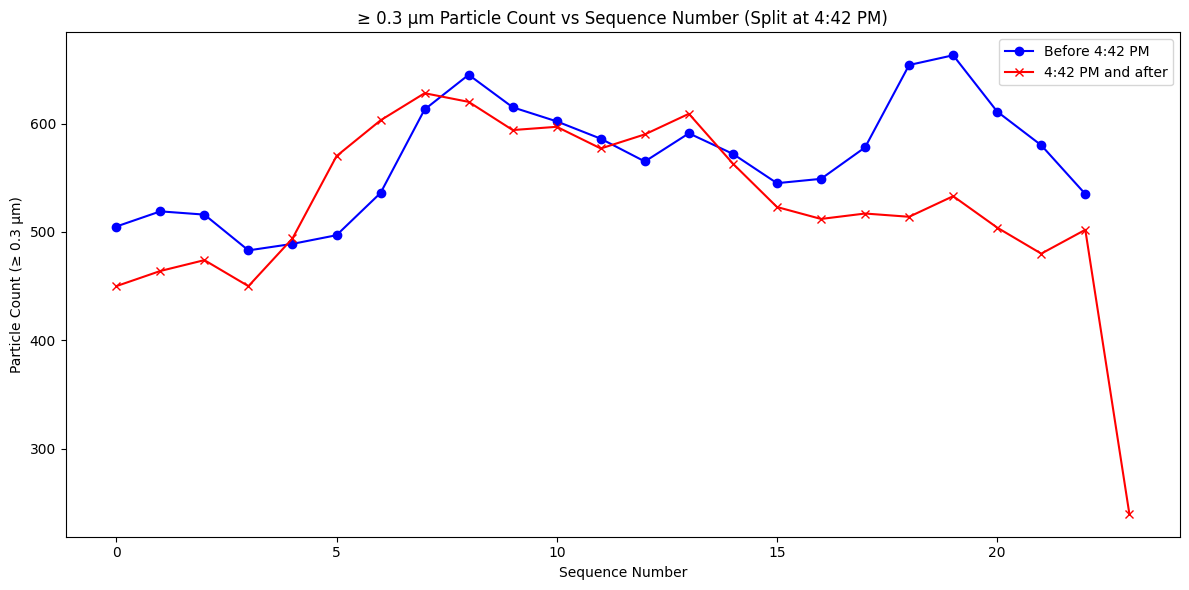

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to your CSV file
file_path = "/Users/vivianzhang/opencs/student/_data/csv-temp (2).csv"

# Column names (ignore the extra time column at the end)
columns = [
    "time",
    "longitude",
    "latitude",
    ">= 0.3µm",
    ">= 0.5µm",
    ">= 1.0µm",
    ">= 2.5µm",
    ">= 5.0µm",
    ">= 10.0µm"
]

# Read CSV and handle "null" as NaN
df = pd.read_csv(file_path, usecols=range(len(columns)), names=columns, header=0, na_values="null")

# Convert 'time' to datetime (today's date + time)
df["time"] = pd.to_datetime(df["time"], format="%I:%M:%S %p", errors="coerce")

# Drop rows with invalid times
df = df.dropna(subset=["time"])

# Convert '>= 0.3µm' column to numeric
df[">= 0.3µm"] = pd.to_numeric(df[">= 0.3µm"], errors="coerce")

# Sort by time and reset index for sequence number
df = df.sort_values("time").reset_index(drop=True)

# Split the data at 4:42 PM
split_time = pd.to_datetime("4:42:00 PM", format="%I:%M:%S %p")
before_split = df[df["time"] < split_time].reset_index(drop=True)
after_split = df[df["time"] >= split_time].reset_index(drop=True)

# Plotting >= 0.3µm particle count
plt.figure(figsize=(12, 6))
plt.plot(before_split.index, before_split[">= 0.3µm"], color="blue", marker="o", linestyle="-", label="Before 4:42 PM")
plt.plot(after_split.index, after_split[">= 0.3µm"], color="red", marker="x", linestyle="-", label="4:42 PM and after")

plt.xlabel("Sequence Number")
plt.ylabel("Particle Count (≥ 0.3 µm)")
plt.title("≥ 0.3 µm Particle Count vs Sequence Number (Split at 4:42 PM)")
plt.legend()
plt.tight_layout()
plt.show()


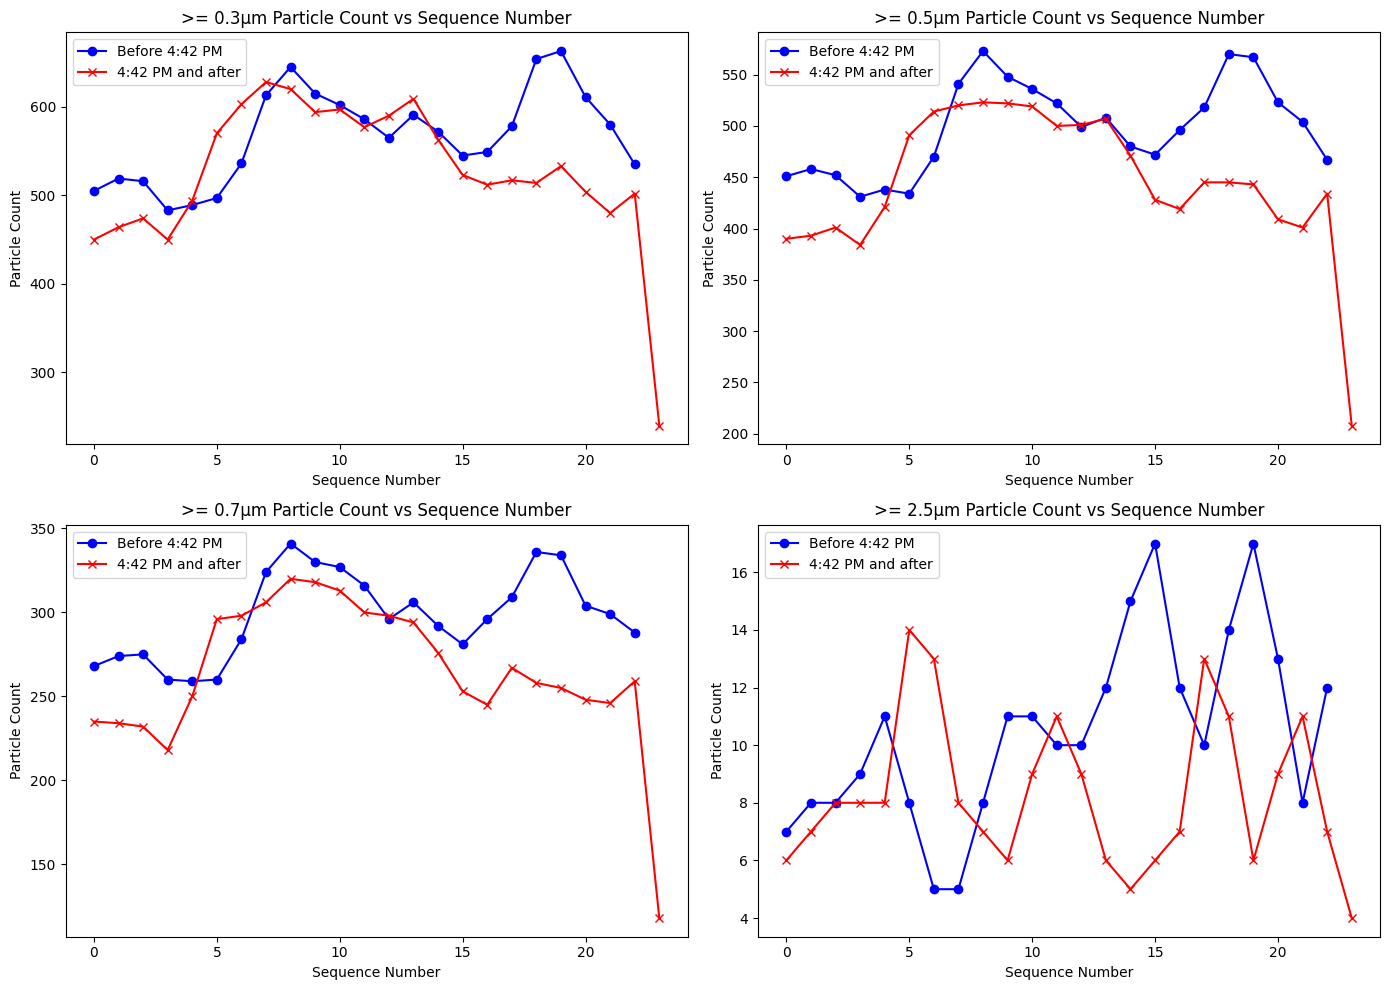

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Path to your CSV file
file_path = "/Users/vivianzhang/opencs/student/_data/csv-temp (2).csv"

# Column names (ignore the extra time column at the end)
columns = [
    "time",
    "longitude",
    "latitude",
    ">= 0.3µm",
    ">= 0.5µm",
    ">= 1.0µm",
    ">= 2.5µm",
    ">= 5.0µm",
    ">= 10.0µm"
]

# Read CSV and handle "null" as NaN
df = pd.read_csv(file_path, usecols=range(len(columns)), names=columns, header=0, na_values="null")

# Convert 'time' to datetime (today's date + time)
df["time"] = pd.to_datetime(df["time"], format="%I:%M:%S %p", errors="coerce")

# Drop rows with invalid times
df = df.dropna(subset=["time"])

# Create 0.7 µm as average of 0.5µm and 1.0µm
df[">= 0.7µm"] = ((df[">= 0.5µm"] + df[">= 1.0µm"]) / 2).round().astype(int)

# Sort by time and reset index for sequence number
df = df.sort_values("time").reset_index(drop=True)

# Split the data at 4:42 PM
split_time = pd.to_datetime("4:42:00 PM", format="%I:%M:%S %p")
before_split = df[df["time"] < split_time].reset_index(drop=True)
after_split = df[df["time"] >= split_time].reset_index(drop=True)

# Particle sizes to plot
particle_sizes = [">= 0.3µm", ">= 0.5µm", ">= 0.7µm", ">= 2.5µm"]

# Create 4-panel figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # flatten 2x2 array for easy iteration

for i, col in enumerate(particle_sizes):
    ax = axes[i]
    ax.plot(before_split.index, before_split[col], color="blue", marker="o", linestyle="-", label="Before 4:42 PM")
    ax.plot(after_split.index, after_split[col], color="red", marker="x", linestyle="-", label="4:42 PM and after")
    ax.set_title(f"{col} Particle Count vs Sequence Number")
    ax.set_xlabel("Sequence Number")
    ax.set_ylabel("Particle Count")
    ax.legend()

plt.tight_layout()
plt.show()
